In [2]:
import pandas as pd
import geopandas
import matplotlib.pyplot as plt
import math


from utils import aggregate_by_prefix, print_stata_variable_labels

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

FINE_BLOCKS = True  # True for blocks (biz paper), False for block groups (base paper)

block_id = "48113"
local_epsg = "epsg:6583"

#### Census business data

In [ ]:
biz_controls = pd.read_stata("/Volumes/ukiki/3.code/dallas_biz/data/census/biz_env_controls.dta")
biz_controls.rename(columns={"blkidfp10": "FIPS"}, inplace=True)
biz_controls.head()

In [ ]:
if FINE_BLOCKS:
    detailed = pd.read_stata("/Volumes/ukiki/3.code/dallas_biz/data/census/businesses_2010_aggregated.dta")
    detailed.rename(columns={"blkidfp10": "FIPS"}, inplace=True)
    biz = detailed
    biz_full = biz.iloc[:, -32:-1].columns
else:
    detailed = pd.read_stata("/Volumes/ukiki/3.code/dallas_biz/data/census/businesses_2010_aggregated.dta")
    detailed = aggregate_by_prefix(detailed, "blkidfp10", "FIPS")

    detailed["employees_total"] = detailed[
        ["bcnsmr_lnemp10a", "whitecollar_lnemp10a", "bluecollar_lnemp10a"]
    ].sum(axis=1)
    biz = detailed[["FIPS", "employees_total"]]

biz

#### Census Shapes (with demographics, POIs, transit stops)

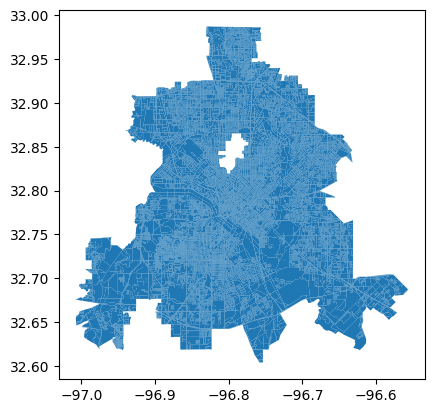

In [7]:
dallas_city = geopandas.read_file("/Volumes/ukiki/3.code/dallas_biz/data/census/dallas_blockgroup")
dallas_city_fips = set(dallas_city["FIPS"].astype(str))

# Load census data and filter for Dallas City
if FINE_BLOCKS:
    census = geopandas.read_file("/Volumes/ukiki/3.code/dallas_biz/data/census/tl_2010_48113_tabblock10")
    census = census[census["GEOID10"].str[:12].isin(dallas_city_fips)]
    census.rename(columns={"GEOID10": "FIPS"}, inplace=True)
else:
    census = geopandas.read_file("/Volumes/ukiki/3.code/dallas_biz/data/census/census_2010.dta")[["OBJECTID", "FIPS", "geometry"]]
    census_demo = pd.read_stata("/Volumes/ukiki/3.code/dallas_biz/data/census/bg_census_2010.dta.dta")
    census = pd.merge(
        census_demo, census, left_on="bgidfp10", right_on="FIPS", how="left"
    )
    census.fillna(0, inplace=True)

    remap = {
        "gpop10": "POPULATION",
        "gavghhinc10": "INCOME",
        "gavhhsize10": "AVG_HH_SIZE",
        "gwhite10": "WHITE",
        "gblack10": "BLACK",
        "gasian10": "ASIAN",
        "glatino10": "HISPANIC",
        "gothrac10": "OTHER",
    }

    census.rename(columns=remap, inplace=True)

    census = census[census["FIPS"].isin(dallas_city_fips)]
    census = census[census["POPULATION"] > 0]

    racial_ethnic_cols = [
        "WHITE",
        "BLACK",
        "ASIAN",
        "HISPANIC",
        "OTHER",
    ]
    demographic_cols = ["POPULATION", "INCOME", "AVG_HH_SIZE"] + racial_ethnic_cols
    other_cols = [
        "OBJECTID",
        "FIPS",
        "geometry",
    ]
    selected_cols = other_cols + demographic_cols

    census = census[selected_cols]
    census = census.loc[(census[racial_ethnic_cols] != 0).any(axis=1)]
    census = geopandas.GeoDataFrame(census, geometry="geometry")

census.plot()
plt.show()

#### Merge Census Datasets

In [ ]:
if FINE_BLOCKS:
    census_merged = census.merge(
        biz, left_on="FIPS", right_on="FIPS", how="left"
    ).merge(biz_controls, left_on="FIPS", right_on="FIPS", how="left")

else:
    census_merged = census.merge(
        biz, left_on="FIPS", right_on="FIPS", how="left"
    ).merge(census_ses, left_on="FIPS", right_on="FIPS", how="left") # This else codes are for base paper

census_merged = census_merged.fillna(0)
print(census_merged.shape)


(22564, 92)


In [ ]:
census_merged.to_file("census_merged_fine.gpkg", index=False)

#### Into jsonl with protocol

In [10]:
def to_coord(geometry, source_crs, local_epsg):
    if geometry is None or geometry.is_empty:
        raise ValueError("Invalid geometry: geometry is None or empty.")

    # Convert to local CRS
    geom_local = geopandas.GeoSeries([geometry], crs=source_crs).to_crs(local_epsg)
    centroid = geom_local.centroid.iloc[0]

    return (float(centroid.x), float(centroid.y))


def get_field(row, col_name, use_log=True):
    if use_log:
        return float(math.log(1 + max(0, row[col_name])))
    else:
        return float(row[col_name])

In [ ]:
# for biz paper

import math
import geopandas
from dcm.protocols import BlockAggregatedBizFeatures

block_features_list = []

for i, row in census_merged.iterrows():
    home_coord = to_coord(row["geometry"], census_merged.crs, local_epsg)

    extra_features = {}
    if "biz_full" in locals():
        for col in biz_full:
            extra_features["log_" + col] = get_field(col, use_log=True)

    block_feature = BlockAggregatedBizFeatures(
        block_id=int(i),  # row index as block_id
        home_coord=home_coord,
        log_consumer_control=get_field(row, "wSpt25bcnsmr_emp10a"),
        log_white_collar_control=get_field(row, "wSpt25whitecollar_emp10a"),
        log_blue_collar_control=get_field(row, "wSpt25bluecollar_emp10a"),
        log_consumer=get_field(row, "bcnsmr_est10a"),
        log_white_collar=get_field(row, "whitecollar_est10a"),
        log_blue_collar=get_field(row, "bluecollar_est10a"),
        consumer_hetero=get_field(row, "consmr_het", False),
        log_emp_consumer=get_field(row, "bcnsmr_lnemp10a"),
        log_emp_white_collar=get_field(row, "whitecollar_lnemp10a"),
        log_emp_blue_collar=get_field(row, "bluecollar_lnemp10a"),
        log_emp_consumer_hetero=get_field(row, "lnemp_consmr_het", False),
        extra_features=extra_features,
    )

    block_features_list.append(block_feature)

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(census_merged)} blocks...")

# Save to JSONL file
print("Saving to block_features.jsonl...")
with open("blocks_fine.jsonl", "w") as f:
    for block_feature in block_features_list:
        f.write(block_feature.model_dump_json() + "\n")